In [1]:
pip install duckdb

   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/13.1 MB 217.9 kB/s eta 0:01:01
   ---------------------------------------- 0.0/13.1 MB 393.8 kB/s eta 0:00:34
    --------------------------------------- 0.3/13.1 MB 2.0 MB/s eta 0:00:07
   - -------------------------------------- 0.6/13.1 MB 3.3 MB/s eta 0:00:04
   --- ------------------------------------ 1.1/13.1 MB 4.9 MB/s eta 0:00:03
   ---- ----------------------------------- 1.6/13.1 MB 6.0 MB/s eta 0:00:02
   ------ --------------------------------- 2.1/13.1 MB 6.6 MB/s eta 0:00:02
   ------ --------------------------------- 2.2/13.1 MB 5.8 MB/s eta 0:00:02
   -------- ------------------------------- 2.7/13.1 MB 6.4 MB/s eta 0:00:02
   --------- ------------------------------ 3.2/13.1 MB 6.8 MB/s eta 0:00:02
   ----------- ---------------------------- 3.6/13.1 MB 7.0 MB/s eta 0:00:02
   ------


[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\Moi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [5]:
# Importer le fichier
import pandas as pd
transactions = pd.read_csv('rev-transactions.csv',sep=',')
transactions.head()

,transaction_id,transactions_type,transactions_currency,amount_usd,transactions_state,ea_cardholderpresence,ea_merchant_mcc,ea_merchant_city,ea_merchant_country,direction,user_id,created_date
0,transaction_0,TRANSFER,AED,4.55,COMPLETED,NaN,NaN,NaN,NaN,OUTBOUND,user_898,2018-04-03 03:34:21.784487
1,transaction_1,CARD_PAYMENT,AED,15.50,COMPLETED,FALSE,4111.0,Dubai,ARE,OUTBOUND,user_1652,2019-03-19 06:15:59.537032
2,transaction_2,CARD_PAYMENT,AED,43.40,COMPLETED,FALSE,5814.0,Dubai,ARE,OUTBOUND,user_1652,2019-03-18 18:53:41.323032
3,transaction_3,TRANSFER,AED,10043.01,COMPLETED,NaN,NaN,NaN,NaN,OUTBOUND,user_1652,2019-03-22 14:20:01.513032
4,transaction_4,CARD_PAYMENT,AED,43.81,COMPLETED,FALSE,5651.0,Abu Dhabi,ARE,OUTBOUND,user_5509,2019-03-22 05:42:50.316652


In [6]:
transactions.shape

(2740075, 12)

In [7]:
transactions.dtypes

transaction_id            object
transactions_type         object
transactions_currency     object
amount_usd               float64
transactions_state        object
ea_cardholderpresence     object
ea_merchant_mcc          float64
ea_merchant_city          object
ea_merchant_country       object
direction                 object
user_id                   object
created_date              object
dtype: object

In [8]:
# valeurs manquantes
valeurs_manquantes = transactions.isnull().sum()
print(valeurs_manquantes)

transaction_id                 0
transactions_type              0
transactions_currency          0
amount_usd                     0
transactions_state             0
ea_cardholderpresence    1170594
ea_merchant_mcc          1158658
ea_merchant_city         1158794
ea_merchant_country      1158979
direction                      0
user_id                        0
created_date                   0
dtype: int64


In [9]:
# Vérifier le nombre total de lignes dupliquées
duplicated_values = transactions.duplicated().sum()
print(duplicated_values)

0


In [10]:
# Valeurs uniques dans chaque colonnes
valeurs_uniques =  transactions.nunique()
print(valeurs_uniques)

transaction_id           2740075
transactions_type             10
transactions_currency         35
amount_usd                 48548
transactions_state             6
ea_cardholderpresence          3
ea_merchant_mcc              664
ea_merchant_city           63253
ea_merchant_country          198
direction                      2
user_id                    18766
created_date             2739658
dtype: int64


In [11]:
# Type de transactions
transaction_counts = transactions["transactions_type"].value_counts()
transaction_counts



transactions_type
CARD_PAYMENT    1475780
TRANSFER         500409
TOPUP            388331
EXCHANGE         159148
ATM               93675
CASHBACK          82789
FEE               23659
CARD_REFUND       11962
TAX                2829
REFUND             1493
Name: count, dtype: int64

In [12]:
# Nombre de monnaies
currency = transactions["transactions_currency"].value_counts()
currency

transactions_currency
EUR    1160135
GBP     887795
PLN     231583
RON     167806
USD      80639
CZK      44970
CHF      39716
SEK      26804
AUD      16871
NOK      14271
DKK      14058
CAD       8772
HUF       8408
TRY       4429
AED       3774
NZD       3727
ILS       3563
BTC       3327
JPY       3200
XRP       2932
ZAR       2897
SGD       2207
THB       2159
HKD       1818
ETH       1145
MAD        925
LTC        584
BCH        326
QAR        314
HRK        287
BGN        257
MXN        159
INR        148
RUB         58
SAR         11
Name: count, dtype: int64

In [13]:
# Etat des transactions
state = transactions["transactions_state"].value_counts()
state

transactions_state
COMPLETED    2407968
DECLINED      155286
REVERTED      112618
FAILED         41053
PENDING        21492
CANCELLED       1658
Name: count, dtype: int64

In [14]:
# indicateur d'un paiement physique
e_cardholderpresence = transactions["ea_cardholderpresence"].value_counts()
e_cardholderpresence

ea_cardholderpresence
FALSE      1275460
TRUE        288489
UNKNOWN       5532
Name: count, dtype: int64

Pour le code marchand, créer une regroupement de catégories

In [15]:
e_city = transactions["ea_merchant_city"].value_counts()
e_city

ea_merchant_city
London           92745
Bucuresti        33227
Vilnius          30379
Dublin           25246
35314369001      23157
                 ...  
Charles-de-ga        1
Perieni              1
Korat                1
Ellemere Port        1
2068964960           1
Name: count, Length: 63253, dtype: int64

In [16]:
e_city = transactions["ea_merchant_country"].value_counts()
e_city

ea_merchant_country
GBR    455924
IRL    122993
USA    100203
FRA     99637
POL     83431
        ...  
GNQ         1
SCH         1
SGB         1
LSO         1
COD         1
Name: count, Length: 198, dtype: int64

In [17]:
e_direction = transactions["direction"].value_counts()
e_direction

direction
OUTBOUND    2209795
INBOUND      530280
Name: count, dtype: int64

In [18]:
#  Fonction qui attribue une catégorie selon la valeur du MCC
def category_mcc(mcc):
    if 1500 <=mcc<= 2999:
       return "General services"
    elif 4000 <=mcc<= 4799:
       return "Transportation services"
    elif 4800 <=mcc<= 4999:
       return "Utility services"
    elif 5000 <=mcc<= 5599:
       return "Retail outlet services"
    elif 5000 <=mcc<= 5699:
       return "Clothing stores"
    elif 5700 <=mcc<= 7299:
       return "Miscellaneous stores" 
    elif 7300 <=mcc<= 7999:
       return "Business services"
    elif 8000 <=mcc<= 8999:
       return "Professional services and membership organizations"
    elif 3000 <=mcc<= 3299:
       return "Airlines"
    elif 3000 <=mcc<= 3299:
       return "Car rental"
    elif 3500 <=mcc<= 3999:
       return "Lodging"
    else:
       return "Unknown"

In [19]:
# Appliquer la fonction category_mcc à la colonne 'ea_merchant_mcc'
transactions["merchant_category"] = transactions["ea_merchant_mcc"].apply(lambda x: category_mcc(x) if pd.notna(x) else "Unknown")
transactions.head()

,transaction_id,transactions_type,transactions_currency,amount_usd,transactions_state,ea_cardholderpresence,ea_merchant_mcc,ea_merchant_city,ea_merchant_country,direction,user_id,created_date,merchant_category
0,transaction_0,TRANSFER,AED,4.55,COMPLETED,NaN,NaN,NaN,NaN,OUTBOUND,user_898,2018-04-03 03:34:21.784487,Unknown
1,transaction_1,CARD_PAYMENT,AED,15.50,COMPLETED,FALSE,4111.0,Dubai,ARE,OUTBOUND,user_1652,2019-03-19 06:15:59.537032,Transportation services
2,transaction_2,CARD_PAYMENT,AED,43.40,COMPLETED,FALSE,5814.0,Dubai,ARE,OUTBOUND,user_1652,2019-03-18 18:53:41.323032,Miscellaneous stores
3,transaction_3,TRANSFER,AED,10043.01,COMPLETED,NaN,NaN,NaN,NaN,OUTBOUND,user_1652,2019-03-22 14:20:01.513032,Unknown
4,transaction_4,CARD_PAYMENT,AED,43.81,COMPLETED,FALSE,5651.0,Abu Dhabi,ARE,OUTBOUND,user_5509,2019-03-22 05:42:50.316652,Clothing stores


In [20]:
# Compter le nombre de transactions par catégorie
category_counts = transactions["merchant_category"].value_counts()
category_counts

merchant_category
Unknown                                               1171619
Miscellaneous stores                                   745437
Retail outlet services                                 440610
Transportation services                                179825
Business services                                       94252
Clothing stores                                         47349
Utility services                                        25974
Professional services and membership organizations      21216
Airlines                                                 8286
Lodging                                                  4044
General services                                         1463
Name: count, dtype: int64

In [21]:
df = transactions.copy()
df["merchant_category"] = df["ea_merchant_mcc"].apply(lambda x: category_mcc(x) if pd.notna(x) else "Unknown")
df

,transaction_id,transactions_type,transactions_currency,amount_usd,transactions_state,ea_cardholderpresence,ea_merchant_mcc,ea_merchant_city,ea_merchant_country,direction,user_id,created_date,merchant_category
0,transaction_0,TRANSFER,AED,4.55,COMPLETED,NaN,NaN,NaN,NaN,OUTBOUND,user_898,2018-04-03 03:34:21.784487,Unknown
1,transaction_1,CARD_PAYMENT,AED,15.50,COMPLETED,FALSE,4111.0,Dubai,ARE,OUTBOUND,user_1652,2019-03-19 06:15:59.537032,Transportation services
2,transaction_2,CARD_PAYMENT,AED,43.40,COMPLETED,FALSE,5814.0,Dubai,ARE,OUTBOUND,user_1652,2019-03-18 18:53:41.323032,Miscellaneous stores
3,transaction_3,TRANSFER,AED,10043.01,COMPLETED,NaN,NaN,NaN,NaN,OUTBOUND,user_1652,2019-03-22 14:20:01.513032,Unknown
4,transaction_4,CARD_PAYMENT,AED,43.81,COMPLETED,FALSE,5651.0,Abu Dhabi,ARE,OUTBOUND,user_5509,2019-03-22 05:42:50.316652,Clothing stores
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2740070,transaction_2740070,TRANSFER,EUR,1.70,COMPLETED,NaN,NaN,NaN,NaN,OUTBOUND,user_16319,2019-04-30 10:10:36.810961,Unknown
2740071,transaction_2740071,TRANSFER,EUR,17.02,COMPLETED,NaN,NaN,NaN,NaN,INBOUND,user_18233,2019-04-30 18:42:45.443443,Unknown
2740072,transaction_2740072,TRANSFER,EUR,4.26,COMPLETED,NaN,NaN,NaN,NaN,OUTBOUND,user_13991,2019-05-01 11:34:25.078035,Unknown
2740073,transaction_2740073,TRANSFER,EUR,1.70,COMPLETED,NaN,NaN,NaN,NaN,OUTBOUND,user_12529,2019-04-30 16:51:26.445105,Unknown


In [22]:
df.dtypes

transaction_id            object
transactions_type         object
transactions_currency     object
amount_usd               float64
transactions_state        object
ea_cardholderpresence     object
ea_merchant_mcc          float64
ea_merchant_city          object
ea_merchant_country       object
direction                 object
user_id                   object
created_date              object
merchant_category         object
dtype: object

In [23]:
duplicated_values = df.duplicated().sum()
print(duplicated_values)

0


In [24]:
# valeurs manquantes
valeurs_manquantes = df.isnull().sum()
print(valeurs_manquantes)

transaction_id                 0
transactions_type              0
transactions_currency          0
amount_usd                     0
transactions_state             0
ea_cardholderpresence    1170594
ea_merchant_mcc          1158658
ea_merchant_city         1158794
ea_merchant_country      1158979
direction                      0
user_id                        0
created_date                   0
merchant_category              0
dtype: int64


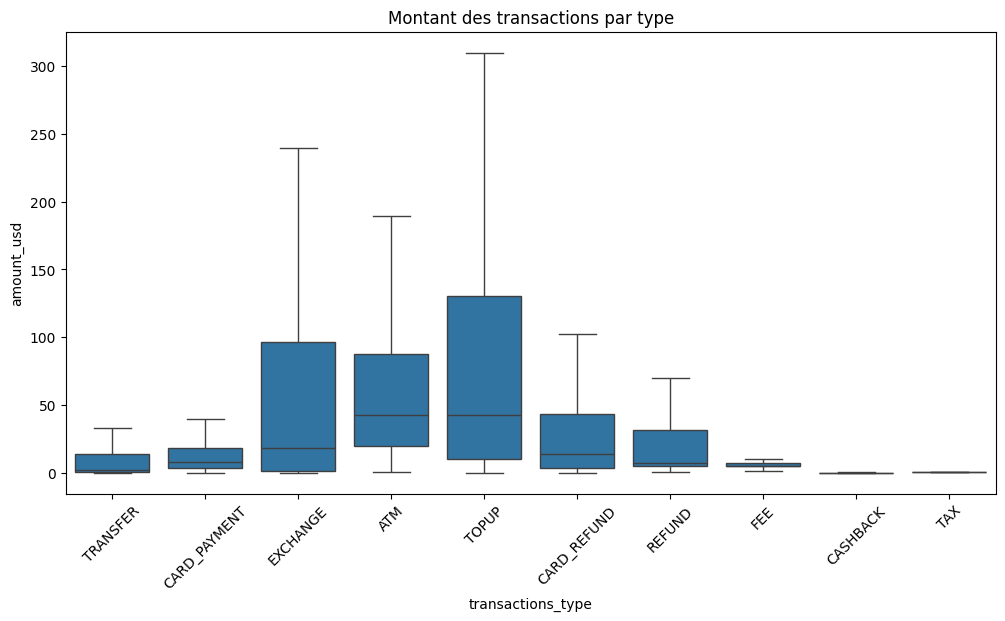

In [25]:
# Corrélation entre variables numériques
# Relation entre mohntant (amount_usd) et catégories de transactions
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x="transactions_type", y="amount_usd", showfliers=False)  # Enlève les outliers
plt.xticks(rotation=45)
plt.title("Montant des transactions par type")
plt.show()

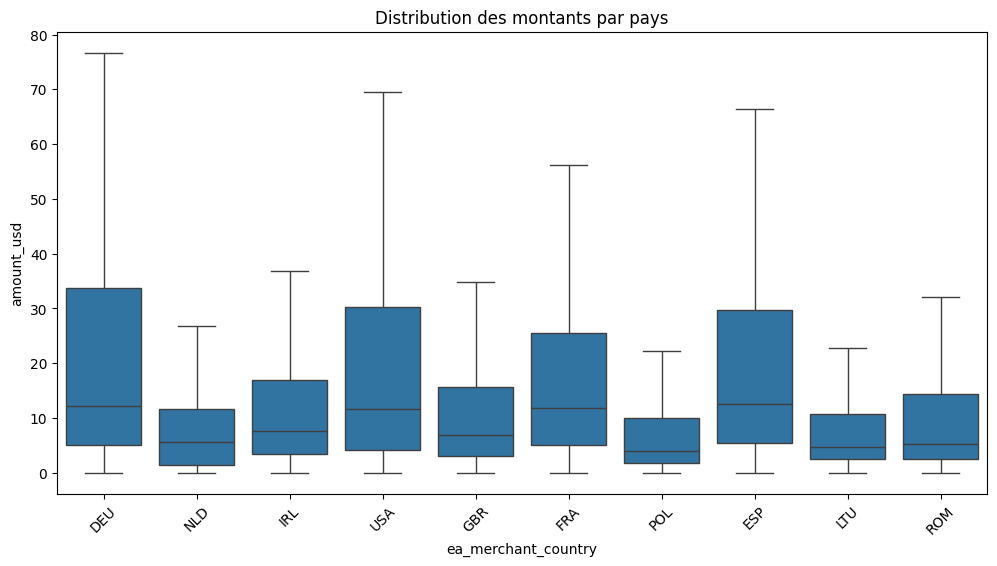

In [26]:
# Relation entre le pays (ea_merchant_country) et les montants des transactions
top_countries = df["ea_merchant_country"].value_counts().head(10).index  # Top 10 pays
df_filtered = df[df["ea_merchant_country"].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.boxplot(data=df_filtered, x="ea_merchant_country", y="amount_usd", showfliers=False)
plt.xticks(rotation=45)
plt.title("Distribution des montants par pays")
plt.show()

In [27]:
pip install scipy

Note: you may need to restart the kernel to use updated packages.


In [28]:
# Test du Khi-2 pour voir  si certaines catégories sont significativement associées entre elles
from scipy.stats import chi2_contingency

# Création d'une table de contingence
#contingency_table = pd.crosstab(df['user_id'], df['transactions_type'])

# Calcul du test du khi-2
#chi2, p, dof, expected = chi2_contingency(contingency_table)

#print(f"Statistique Khi-2 : {chi2}")
#print(f"P-value : {p}")

#if p < 0.05:
    #print("Il existe une association significative entre les deux variables.")
#else:
    #print("Aucune association significative détectée.")

In [29]:
import numpy as np
import pandas as pd

# 1. Créer une table de contingence entre deux variables catégorielles
contingency_table = pd.crosstab(df['amount_usd'], df['merchant_category'])

# 2. Appliquer le test du Khi-2
chi2, p, dof, expected = chi2_contingency(contingency_table)

# 3. Définir la fonction pour calculer le V de Cramer
def cramers_v(chi2, n, r, c):
    return np.sqrt(chi2 / (n * (min(r-1, c-1))))

# 4. Calcul du V de Cramer
v_cramer = cramers_v(chi2, df.shape[0], *contingency_table.shape)

# 5. Afficher les résultats
print(f"Chi-2 : {chi2:.3f}")
print(f"P-value : {p:.5f}")
print(f"V de Cramer : {v_cramer:.3f}")


Chi-2 : 3204072.752
P-value : 0.00000
V de Cramer : 0.342


In [64]:
custom_colors = ['#2b69db', '#a7d5fa', '#eea8ff','#9976ff', '#d9d9d9','#dc63f9']

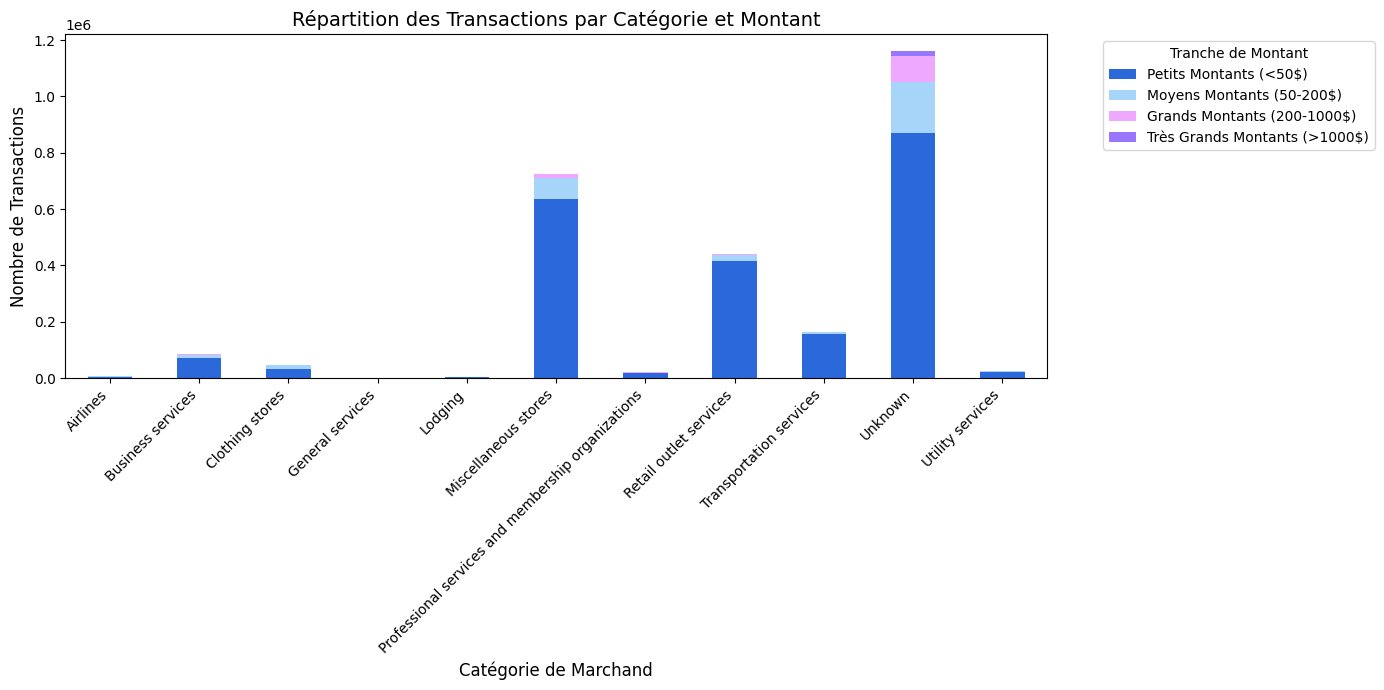

In [65]:
import matplotlib.pyplot as plt

# Définition des couleurs personnalisées
# custom_colors = ['#000000', '#2b69db', '#a7d5fa', '#eea8ff']

# Création du graphique en barres empilées avec la palette personnalisée
fig, ax = plt.subplots(figsize=(14, 7))
transactions_by_category.plot(kind='bar', stacked=True, color=custom_colors, ax=ax)

# Personnalisation du graphique
ax.set_title("Répartition des Transactions par Catégorie et Montant", fontsize=14)
ax.set_xlabel("Catégorie de Marchand", fontsize=12)
ax.set_ylabel("Nombre de Transactions", fontsize=12)
ax.legend(title="Tranche de Montant", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajustement des étiquettes de l'axe des X pour éviter le chevauchement
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Ajustement de l'affichage
plt.tight_layout()
plt.show()

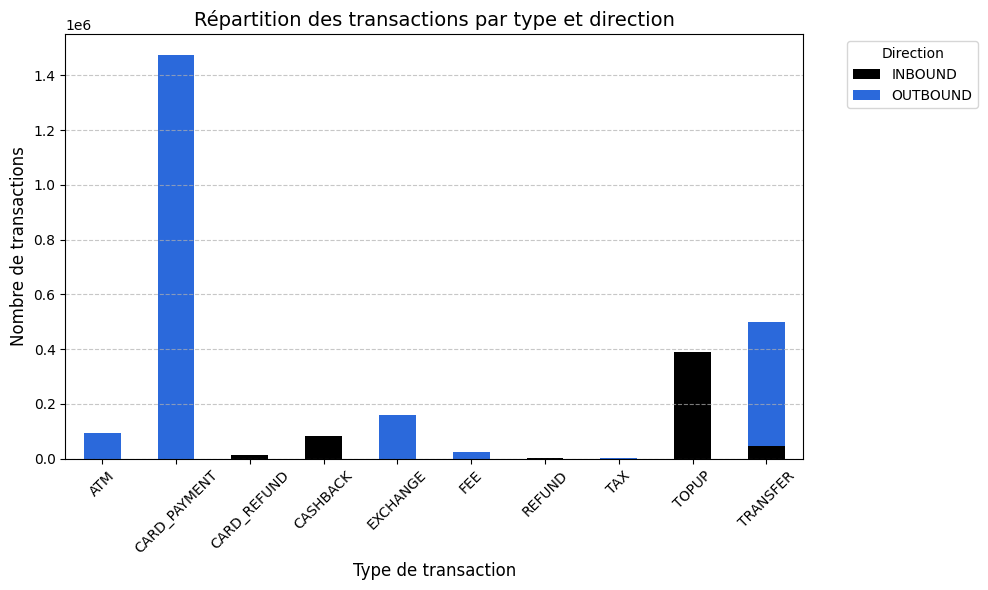

In [66]:
import matplotlib.pyplot as plt

# Définition des couleurs personnalisées
custom_colors = ['#000000', '#2b69db', '#a7d5fa', '#eea8ff']

# Comptage des transactions par type et direction
df_grouped = df.groupby(["transactions_type", "direction"])["transaction_id"].count().unstack()

# Création du graphique en barres empilées avec couleurs personnalisées
df_grouped.plot(kind="bar", stacked=True, figsize=(10, 6), color=custom_colors)

# Personnalisation du graphique
plt.title("Répartition des transactions par type et direction", fontsize=14)
plt.xlabel("Type de transaction", fontsize=12)
plt.ylabel("Nombre de transactions", fontsize=12)
plt.legend(title="Direction", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)

# Affichage du graphique
plt.tight_layout()
plt.show()

C:\Users\Moi\AppData\Local\Temp\ipykernel_4268\1176382742.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="direction", y="amount_usd", palette= custom_colors)
C:\Users\Moi\AppData\Local\Temp\ipykernel_4268\1176382742.py:5: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.boxplot(data=df, x="direction", y="amount_usd", palette= custom_colors)


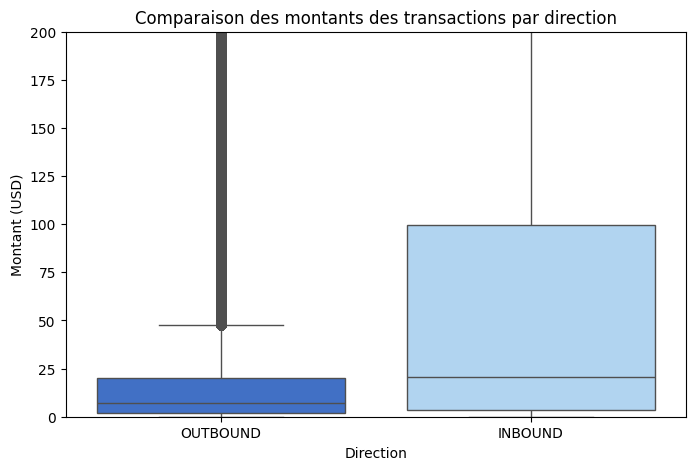

In [71]:
custom_colors = ['#2b69db', '#a7d5fa', '#eea8ff','#9976ff', '#d9d9d9','#dc63f9']

# amount_usd et direction
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="direction", y="amount_usd", palette= custom_colors)

# Personnalisation
plt.title("Comparaison des montants des transactions par direction")
plt.xlabel("Direction")
plt.ylabel("Montant (USD)")
plt.ylim(0, df["amount_usd"].quantile(0.95))  # Filtrer les valeurs extrêmes

# Affichage
plt.show()

C:\Users\Moi\AppData\Local\Temp\ipykernel_4268\4010114931.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_currency_amount, x="transactions_currency", y="amount_usd", palette=custom_colors)
C:\Users\Moi\AppData\Local\Temp\ipykernel_4268\4010114931.py:13: UserWarning: 
The palette list has fewer values (5) than needed (35) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=df_currency_amount, x="transactions_currency", y="amount_usd", palette=custom_colors)


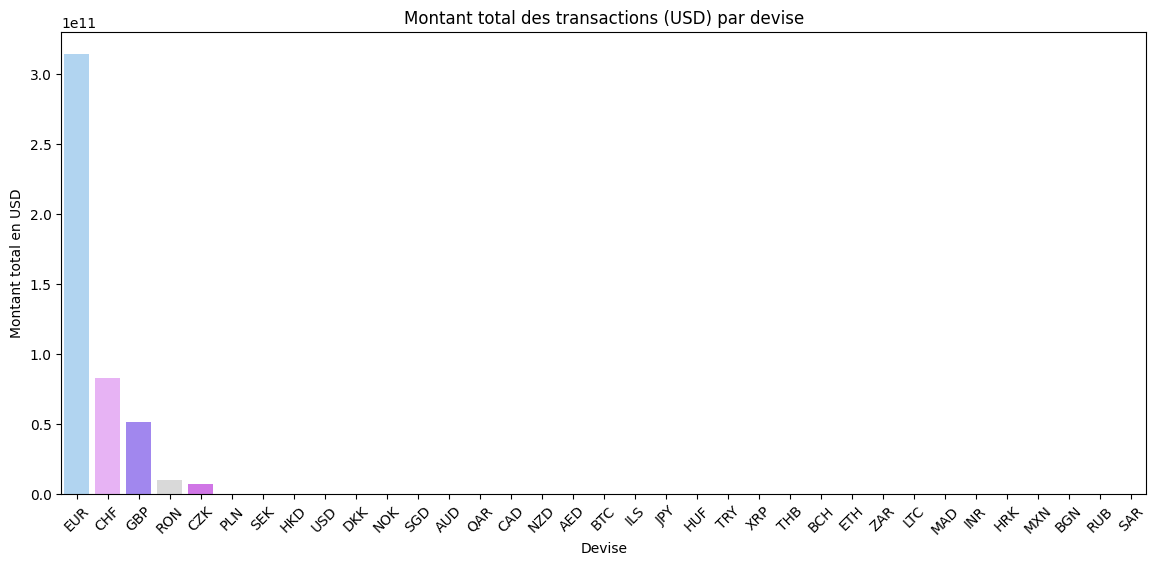

In [73]:
# amount_usd et transactions_currency

custom_colors = ['#a7d5fa', '#eea8ff','#9976ff', '#d9d9d9','#dc63f9']

# Regrouper les montants par devise
df_currency_amount = df.groupby("transactions_currency")["amount_usd"].sum().reset_index()

# Trier les devises par montant total
df_currency_amount = df_currency_amount.sort_values(by="amount_usd", ascending=False)

# Création du barplot
plt.figure(figsize=(14, 6))
sns.barplot(data=df_currency_amount, x="transactions_currency", y="amount_usd", palette=custom_colors)

# Personnalisation
plt.title("Montant total des transactions (USD) par devise")
plt.xlabel("Devise")
plt.ylabel("Montant total en USD")
plt.xticks(rotation=45)

# Affichage
plt.show()

Cette figure montre que ces devises (EUR, CHF, GBP, CZK, RON) ont les montants les plus élevés en USD.

L’EUR, CHF et GBP sont attendus, car ce sont des devises majeures en Europe avec des valeurs relativement élevées.
CZK (Couronne tchèque) et RON (Leu roumain) peuvent surprendre, mais cela pourrait être dû à de grosses transactions dans ces pays ou des partenaires commerciaux spécifiques.
Si le montant total est élevé, ça peut venir soit d’un grand nombre de transactions, soit de quelques grosses transactions.

C:\Users\Moi\AppData\Local\Temp\ipykernel_4268\1599815395.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=transactions_state_counts.index, y=transactions_state_counts.values, palette=custom_colors)
C:\Users\Moi\AppData\Local\Temp\ipykernel_4268\1599815395.py:11: UserWarning: 
The palette list has fewer values (5) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(x=transactions_state_counts.index, y=transactions_state_counts.values, palette=custom_colors)


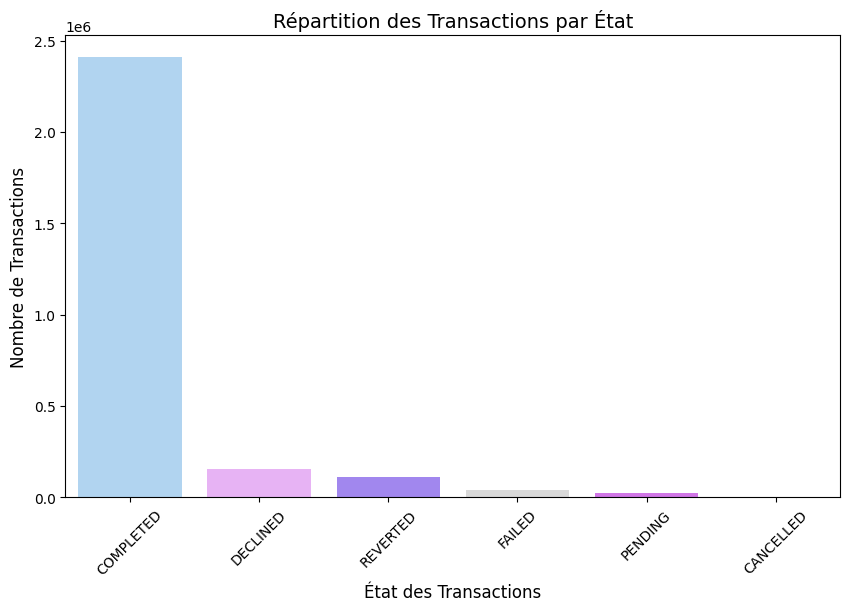

In [74]:
# amount_usd et transactions_currency

import matplotlib.pyplot as plt
import seaborn as sns

# Comptage des transactions par état
transactions_state_counts = df['transactions_state'].value_counts()

# Création du graphique
plt.figure(figsize=(10, 6))
sns.barplot(x=transactions_state_counts.index, y=transactions_state_counts.values, palette=custom_colors)

# Personnalisation
plt.title("Répartition des Transactions par État", fontsize=14)
plt.xlabel("État des Transactions", fontsize=12)
plt.ylabel("Nombre de Transactions", fontsize=12)
plt.xticks(rotation=45)

# Affichage
plt.show()

In [56]:
print(df['ea_cardholderpresence'].value_counts())

ea_cardholderpresence
FALSE      1275460
unknown    1170594
TRUE        288489
UNKNOWN       5532
Name: count, dtype: int64


In [35]:
valeurs_uniques =  df.nunique()
print(valeurs_uniques)

transaction_id           2740075
transactions_type             10
transactions_currency         35
amount_usd                 48548
transactions_state             6
ea_cardholderpresence          3
ea_merchant_mcc              664
ea_merchant_city           63253
ea_merchant_country          198
direction                      2
user_id                    18766
created_date             2739658
merchant_category             11
amount_category                4
dtype: int64


In [36]:
# Gestion des valeurs manquantes
df["ea_cardholderpresence"].fillna("unknown", inplace=True)
df["direction"].fillna("OUTBOUND", inplace=True)
df.dropna(subset=["user_id"], inplace=True)
df.dropna(subset=["created_date"], inplace=True)
df["ea_merchant_mcc"].fillna(9999, inplace=True)
df["ea_merchant_city"].fillna("unknown_city", inplace=True)
df["ea_merchant_country"].fillna("unknown_country", inplace=True)


In [37]:
valeurs_manquantes = df.isnull().sum()
print(valeurs_manquantes)

transaction_id               0
transactions_type            0
transactions_currency        0
amount_usd                   0
transactions_state           0
ea_cardholderpresence        0
ea_merchant_mcc              0
ea_merchant_city             0
ea_merchant_country          0
direction                    0
user_id                      0
created_date                 0
merchant_category            0
amount_category          58604
dtype: int64


In [38]:
df

,transaction_id,transactions_type,transactions_currency,amount_usd,transactions_state,ea_cardholderpresence,ea_merchant_mcc,ea_merchant_city,ea_merchant_country,direction,user_id,created_date,merchant_category,amount_category
0,transaction_0,TRANSFER,AED,4.55,COMPLETED,unknown,9999.0,unknown_city,unknown_country,OUTBOUND,user_898,2018-04-03 03:34:21.784487,Unknown,Petits Montants (<50$)
1,transaction_1,CARD_PAYMENT,AED,15.50,COMPLETED,FALSE,4111.0,Dubai,ARE,OUTBOUND,user_1652,2019-03-19 06:15:59.537032,Transportation services,Petits Montants (<50$)
2,transaction_2,CARD_PAYMENT,AED,43.40,COMPLETED,FALSE,5814.0,Dubai,ARE,OUTBOUND,user_1652,2019-03-18 18:53:41.323032,Miscellaneous stores,Petits Montants (<50$)
3,transaction_3,TRANSFER,AED,10043.01,COMPLETED,unknown,9999.0,unknown_city,unknown_country,OUTBOUND,user_1652,2019-03-22 14:20:01.513032,Unknown,Très Grands Montants (>1000$)
4,transaction_4,CARD_PAYMENT,AED,43.81,COMPLETED,FALSE,5651.0,Abu Dhabi,ARE,OUTBOUND,user_5509,2019-03-22 05:42:50.316652,Clothing stores,Petits Montants (<50$)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2740070,transaction_2740070,TRANSFER,EUR,1.70,COMPLETED,unknown,9999.0,unknown_city,unknown_country,OUTBOUND,user_16319,2019-04-30 10:10:36.810961,Unknown,Petits Montants (<50$)
2740071,transaction_2740071,TRANSFER,EUR,17.02,COMPLETED,unknown,9999.0,unknown_city,unknown_country,INBOUND,user_18233,2019-04-30 18:42:45.443443,Unknown,Petits Montants (<50$)
2740072,transaction_2740072,TRANSFER,EUR,4.26,COMPLETED,unknown,9999.0,unknown_city,unknown_country,OUTBOUND,user_13991,2019-05-01 11:34:25.078035,Unknown,Petits Montants (<50$)
2740073,transaction_2740073,TRANSFER,EUR,1.70,COMPLETED,unknown,9999.0,unknown_city,unknown_country,OUTBOUND,user_12529,2019-04-30 16:51:26.445105,Unknown,Petits Montants (<50$)


In [39]:
# Création du DataFrame df_user avec les utilisateurs uniques
df_user = df[["user_id"]].drop_duplicates().copy()

# Montant total et moyen des transactions
df_user = df_user.merge(df.groupby("user_id")["amount_usd"].sum().rename("total_spent"), on="user_id", how="left")
df_user = df_user.merge(df.groupby("user_id")["amount_usd"].mean().rename("avg_transaction_amount"), on="user_id", how="left")

# Nombre total de transactions par utilisateur
df_user = df_user.merge(df.groupby("user_id")["transaction_id"].count().rename("total_transactions"), on="user_id", how="left")

# Nombre de transactions entrantes et sortantes
df_inbound = df[df["direction"] == "INBOUND"].groupby("user_id")["transaction_id"].count().rename("inbound_transactions")
df_outbound = df[df["direction"] == "OUTBOUND"].groupby("user_id")["transaction_id"].count().rename("outbound_transactions")

df_user = df_user.merge(df_inbound, on="user_id", how="left").merge(df_outbound, on="user_id", how="left")
df_user[["inbound_transactions", "outbound_transactions"]] = df_user[["inbound_transactions", "outbound_transactions"]].fillna(0)

# Ratio transactions entrantes / total
df_user["inbound_ratio"] = df_user["inbound_transactions"] / df_user["total_transactions"]

# Nombre de marchands différents utilisés
df_user = df_user.merge(df.groupby("user_id")["ea_merchant_mcc"].nunique().rename("unique_merchants"), on="user_id", how="left")

# Catégorie de marchand la plus utilisée
df_user = df_user.merge(df.groupby("user_id")["merchant_category"].agg(lambda x: x.mode()[0] if not x.mode().empty else "Unknown").rename("top_merchant_category"), on="user_id", how="left")

# Ajout du pourcentage d'utilisation de la catégorie principale
df_merchant_category_ratio = df.groupby(["user_id", "merchant_category"])["transaction_id"].count().reset_index()
df_merchant_category_ratio["total_transactions"] = df_merchant_category_ratio.groupby("user_id")["transaction_id"].transform("sum")
df_merchant_category_ratio["category_ratio"] = df_merchant_category_ratio["transaction_id"] / df_merchant_category_ratio["total_transactions"]

df_user = df_user.merge(df_merchant_category_ratio.groupby("user_id")["category_ratio"].max().reset_index(), on="user_id", how="left")

# Ajouter les informations sur le pays
df_user = df_user.merge(df.groupby("user_id")["ea_merchant_country"].agg(lambda x: x.mode()[0] if not x.mode().empty else "Unknown").rename("top_merchant_country"), on="user_id", how="left")

# Ajouter les informations sur la devise
df_user = df_user.merge(df.groupby("user_id")["transactions_currency"].agg(lambda x: x.mode()[0] if not x.mode().empty else "Unknown").rename("top_merchant_currency"), on="user_id", how="left")



In [40]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [41]:
print(df_user.dtypes)

user_id                    object
total_spent               float64
avg_transaction_amount    float64
total_transactions          int64
inbound_transactions      float64
outbound_transactions     float64
inbound_ratio             float64
unique_merchants            int64
top_merchant_category      object
category_ratio            float64
top_merchant_country       object
top_merchant_currency      object
dtype: object


In [42]:
# Supprimer user_id
df_user = df_user.drop(columns=["user_id"])

# One-hot encoding
df_user = pd.get_dummies(df_user, columns=["top_merchant_category","top_merchant_country","top_merchant_currency"], drop_first=True)

In [43]:
print(df_user.dtypes)  # Vérifier que tout est numérique
print(df_user.isnull().sum())  # Vérifier qu’il n’y a pas de valeurs manquantes

total_spent                  float64
avg_transaction_amount       float64
total_transactions             int64
inbound_transactions         float64
outbound_transactions        float64
                              ...   
top_merchant_currency_THB       bool
top_merchant_currency_TRY       bool
top_merchant_currency_USD       bool
top_merchant_currency_XRP       bool
top_merchant_currency_ZAR       bool
Length: 143, dtype: object
total_spent                  0
avg_transaction_amount       0
total_transactions           0
inbound_transactions         0
outbound_transactions        0
                            ..
top_merchant_currency_THB    0
top_merchant_currency_TRY    0
top_merchant_currency_USD    0
top_merchant_currency_XRP    0
top_merchant_currency_ZAR    0
Length: 143, dtype: int64


In [44]:
#from sklearn.preprocessing import LabelEncoder

#encoder = LabelEncoder()
#df_user["top_country"] = encoder.fit_transform(df_user["top_country"])
#df_user["top_category"] = encoder.fit_transform(df_user["top_category"])

In [45]:
from sklearn.preprocessing import MinMaxScaler
import pandas as pd

# Exemple pour scaler df_user et créer un DataFrame
scaler = MinMaxScaler()
df_user_scaled = pd.DataFrame(scaler.fit_transform(df_user), columns=df_user.columns)

In [46]:
import numpy as np

# Vérification des valeurs manquantes dans le dataframe scalé
print(np.any(np.isnan(df_user_scaled)))  # Cela renverra True s'il y a des NaN

False


In [47]:
#from sklearn.impute import SimpleImputer

# Appliquer un imputeur pour remplacer les NaN par la moyenne de chaque colonne
#imputer = SimpleImputer(strategy='mean')
#df_user_scaled = imputer.fit_transform(df_user_scaled)

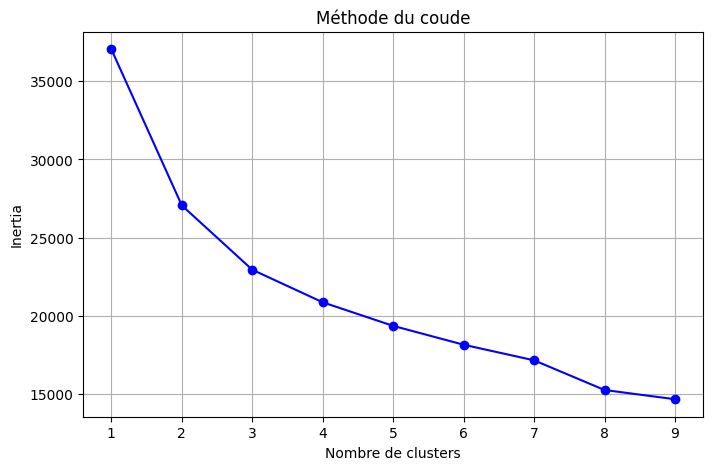

In [48]:
# Méthode du coude (elbow method)
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto', max_iter=300)
    kmeans.fit(df_user_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertia')
plt.title('Méthode du coude')
plt.grid(True)  # Ajout d'une grille pour mieux voir l'épaule du coude
plt.show()

In [49]:
df_user_scaled = df_user_scaled.select_dtypes(include=['float64', 'int64'])

In [50]:
from sklearn.cluster import KMeans
import pandas as pd

# Application de KMeans avec 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42, n_init='auto', max_iter=300)
clusters = kmeans.fit_predict(df_user_scaled)

# Convertir les résultats de la prédiction en DataFrame et ajouter la colonne 'cluster'
df_user['cluster'] = clusters

# Afficher quelques informations sur les clusters obtenus
df_user.groupby('cluster').mean()  # Affiche la moyenne des features par cluster
df_user['cluster'].value_counts()  # Affiche le nombre d'utilisateurs par cluster

cluster
2    6755
0    6575
1    5436
Name: count, dtype: int64

In [51]:
df_user.groupby('cluster').mean()

,total_spent,avg_transaction_amount,total_transactions,inbound_transactions,outbound_transactions,inbound_ratio,unique_merchants,category_ratio,top_merchant_category_Business services,top_merchant_category_Clothing stores,...,top_merchant_currency_PLN,top_merchant_currency_QAR,top_merchant_currency_RON,top_merchant_currency_SEK,top_merchant_currency_SGD,top_merchant_currency_THB,top_merchant_currency_TRY,top_merchant_currency_USD,top_merchant_currency_XRP,top_merchant_currency_ZAR
cluster,,,,,,,,,,,,,,,,,,,,,
0,1.649310e+07,32421.538908,150.848821,21.873156,128.975665,0.180616,20.184335,0.453715,0.026464,0.005171,...,0.108897,0.000000,0.034525,0.007605,0.000304,0.000152,0.000760,0.027529,0.000000,0.001369
1,1.480796e+07,989631.554492,136.830758,30.746873,106.083885,0.402322,12.742458,0.682609,0.002391,0.000184,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,4.111890e+07,271276.975360,148.694597,32.468394,116.226203,0.374144,13.027683,0.665339,0.001184,0.000148,...,0.205774,0.000148,0.112509,0.012435,0.000148,0.000296,0.000888,0.023982,0.000148,0.001036


In [52]:
# Rendre le résultat plus haut lisible
df_user.groupby('cluster').mean().style.set_table_styles(
    [{'selector': 'thead th', 'props': [('text-align', 'center')]}]
)

,total_spent,avg_transaction_amount,total_transactions,inbound_transactions,outbound_transactions,inbound_ratio,unique_merchants,category_ratio,top_merchant_category_Business services,top_merchant_category_Clothing stores,top_merchant_category_Miscellaneous stores,top_merchant_category_Professional services and membership organizations,top_merchant_category_Retail outlet services,top_merchant_category_Transportation services,top_merchant_category_Unknown,top_merchant_category_Utility services,top_merchant_country_AND,top_merchant_country_ARE,top_merchant_country_ARG,top_merchant_country_AUS,top_merchant_country_AUT,top_merchant_country_AZE,top_merchant_country_BEL,top_merchant_country_BFA,top_merchant_country_BGR,top_merchant_country_BHR,top_merchant_country_BHS,top_merchant_country_BLR,top_merchant_country_BMU,top_merchant_country_BOL,top_merchant_country_BRA,top_merchant_country_BRB,top_merchant_country_CAN,top_merchant_country_CHE,top_merchant_country_CHL,top_merchant_country_CHN,top_merchant_country_COL,top_merchant_country_CPV,top_merchant_country_CRI,top_merchant_country_CYP,top_merchant_country_CZE,top_merchant_country_DEU,top_merchant_country_DNK,top_merchant_country_DOM,top_merchant_country_EGY,top_merchant_country_ESP,top_merchant_country_EST,top_merchant_country_FIN,top_merchant_country_FRA,top_merchant_country_GBR,top_merchant_country_GEO,top_merchant_country_GIB,top_merchant_country_GLP,top_merchant_country_GRC,top_merchant_country_HKG,top_merchant_country_HRV,top_merchant_country_HUN,top_merchant_country_IDN,top_merchant_country_IND,top_merchant_country_IRL,top_merchant_country_ISL,top_merchant_country_ISR,top_merchant_country_ITA,top_merchant_country_JAM,top_merchant_country_JOR,top_merchant_country_JPN,top_merchant_country_KEN,top_merchant_country_KHM,top_merchant_country_KOR,top_merchant_country_LCA,top_merchant_country_LKA,top_merchant_country_LTU,top_merchant_country_LUX,top_merchant_country_LVA,top_merchant_country_MAR,top_merchant_country_MCO,top_merchant_country_MDA,top_merchant_country_MEX,top_merchant_country_MLT,top_merchant_country_MNE,top_merchant_country_MOZ,top_merchant_country_MUS,top_merchant_country_MWI,top_merchant_country_MYS,top_merchant_country_NGA,top_merchant_country_NLD,top_merchant_country_NOR,top_merchant_country_NZL,top_merchant_country_PAK,top_merchant_country_PAN,top_merchant_country_PER,top_merchant_country_PHL,top_merchant_country_POL,top_merchant_country_PRT,top_merchant_country_QAT,top_merchant_country_REU,top_merchant_country_ROM,top_merchant_country_ROU,top_merchant_country_RUS,top_merchant_country_SAU,top_merchant_country_SEN,top_merchant_country_SGP,top_merchant_country_SRB,top_merchant_country_SVK,top_merchant_country_SVN,top_merchant_country_SWE,top_merchant_country_THA,top_merchant_country_TUN,top_merchant_country_TUR,top_merchant_country_TWN,top_merchant_country_UGA,top_merchant_country_UKR,top_merchant_country_URY,top_merchant_country_USA,top_merchant_country_VNM,top_merchant_country_ZAF,top_merchant_country_unknown_country,top_merchant_currency_AUD,top_merchant_currency_BGN,top_merchant_currency_CAD,top_merchant_currency_CHF,top_merchant_currency_CZK,top_merchant_currency_DKK,top_merchant_currency_EUR,top_merchant_currency_GBP,top_merchant_currency_HKD,top_merchant_currency_HUF,top_merchant_currency_ILS,top_merchant_currency_JPY,top_merchant_currency_MAD,top_merchant_currency_MXN,top_merchant_currency_NOK,top_merchant_currency_NZD,top_merchant_currency_PLN,top_merchant_currency_QAR,top_merchant_currency_RON,top_merchant_currency_SEK,top_merchant_currency_SGD,top_merchant_currency_THB,top_merchant_currency_TRY,top_merchant_currency_USD,top_merchant_currency_XRP,top_merchant_currency_ZAR
cluster,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
0,16493104.015684,32421.538908,150.848821,21.873156,128.975665,0.180616,20.184335,0.453715,0.026464,0.005171,0.730342,0.003498,0.179620,0.

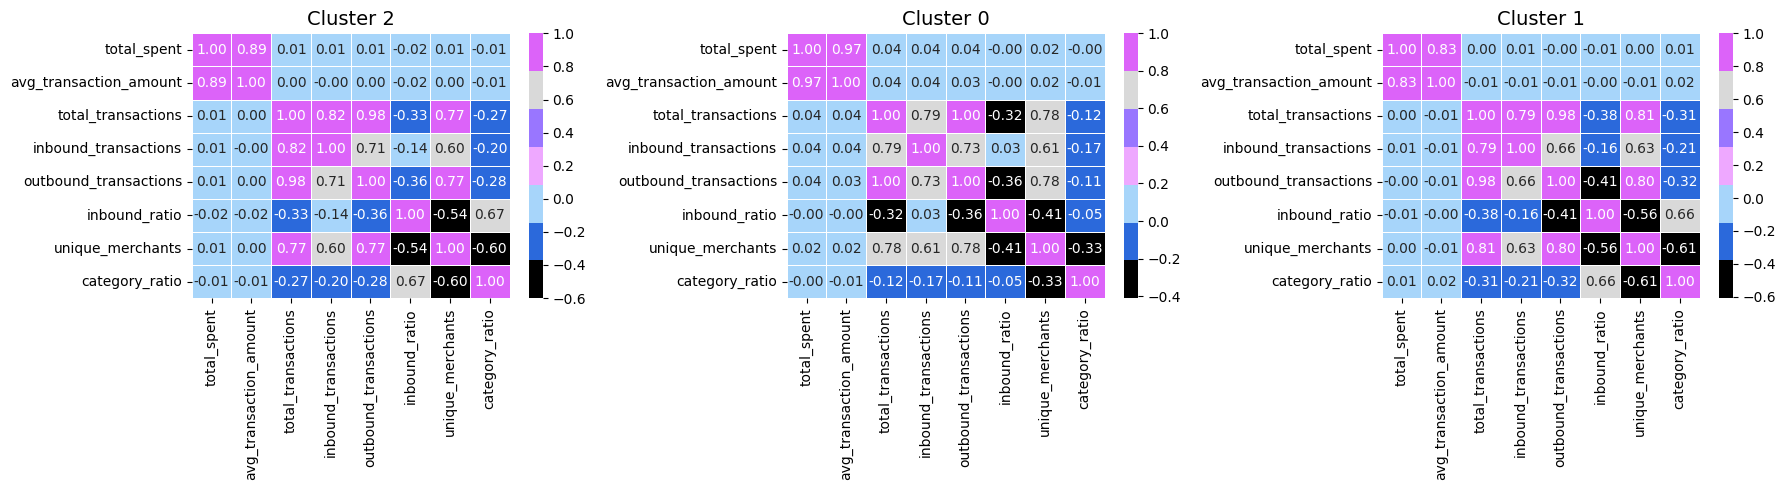

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

custom_colors = ['#000000', '#2b69db', '#a7d5fa', '#eea8ff', '#9976ff', '#d9d9d9', '#dc63f9']

# Assumons que ton DataFrame s'appelle df et contient une colonne 'cluster'
# Vérifie que toutes les colonnes numériques sont bien prises en compte
numerical_columns = df_user.select_dtypes(include=[np.number]).columns.tolist()

# Exclure la colonne 'cluster' des variables à corréler
numerical_columns = [col for col in numerical_columns if col != 'cluster']

# Définition d'une fonction pour tracer les heatmaps par cluster
def plot_correlation_heatmaps(df_user, numerical_columns):
    clusters = df_user['cluster'].unique()
    num_clusters = len(clusters)

    fig, axes = plt.subplots(1, num_clusters, figsize=(6 * num_clusters, 5))
    
    if num_clusters == 1:
        axes = [axes]  # Si un seul cluster, on le met sous forme de liste
    
    for i, cluster in enumerate(clusters):
        df_cluster = df_user[df_user['cluster'] == cluster][numerical_columns]
        corr_matrix = df_cluster.corr()

        sns.heatmap(corr_matrix, annot=True, cmap=custom_colors, fmt=".2f", linewidths=0.5, ax=axes[i])
        axes[i].set_title(f'Cluster {cluster}', fontsize=14)

    plt.tight_layout()
    plt.show()

# Exécution de la fonction
plot_correlation_heatmaps(df_user, numerical_columns)